In [1]:
# %% Import libraries
import numpy as np
import cv2 as cv
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json
%matplotlib inline

In [2]:
# Configure the calibration type and image source directory
cal_type = 'chessboard'  # Options: 'chessboard',', 'circles'
image_dir = Path('/Users/artsloan/Dropbox/Documents/Code/research/ARES/ATHENA Resources/Nebula camera calibration images/chessboard')

In [3]:
# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)
calibration_flags = cv.fisheye.CALIB_RECOMPUTE_EXTRINSIC+cv.fisheye.CALIB_CHECK_COND+cv.fisheye.CALIB_FIX_SKEW

obj_points = [] # Points in real world space
img_points = [] # Points in image plane

if cal_type == 'chessboard':
    pattern_size = (9,6)
    obj_p = np.zeros((1, pattern_size[1]*pattern_size[0], 3), np.float32)
    obj_p[0,:,:2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)*0.025

    for img_file in image_dir.glob('*.jpg'):
        img = cv.imread(str(img_file))
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        ret, corners = cv.findChessboardCorners(gray, 
                                                pattern_size, 
                                                cv.CALIB_CB_ADAPTIVE_THRESH+cv.CALIB_CB_FAST_CHECK+cv.CALIB_CB_NORMALIZE_IMAGE)
        if ret:
            obj_points.append(obj_p)
            corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
            img_points.append(corners2)

    # ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(obj_points, img_points, gray.shape[::-1], None, None)
    ret, K, D, rvecs, tvecs = cv.fisheye.calibrate(obj_points, img_points, gray.shape[::-1], None, None, None, None, calibration_flags, (cv.TERM_CRITERIA_EPS+cv.TERM_CRITERIA_MAX_ITER, 30, 1e-6))
    
    if ret:
        print(" Camera matrix:")
        print(K)

        print("\n Distortion coefficient:")
        print(D)
        
        data={'camera_matrix':K.tolist(), 'distortion_coefficients':D.tolist(),'fisheye':True}
        with open('camera_calibration.json', 'w') as f:
            json.dump(data, f)  

elif cal_type == 'circles':
    pattern_size = (4, 11)
    obj_p = np.zeros((44, 3),np.float32)  # In this asymmetric circle grid, 44 circles are adopted.
    obj_p[0]  = (0  , 0  , 0)
    obj_p[1]  = (0  , 72 , 0)
    obj_p[2]  = (0  , 144, 0)
    obj_p[3]  = (0  , 216, 0)
    obj_p[4]  = (36 , 36 , 0)
    obj_p[5]  = (36 , 108, 0)
    obj_p[6]  = (36 , 180, 0)
    obj_p[7]  = (36 , 252, 0)
    obj_p[8]  = (72 , 0  , 0)
    obj_p[9]  = (72 , 72 , 0)
    obj_p[10] = (72 , 144, 0)
    obj_p[11] = (72 , 216, 0)
    obj_p[12] = (108, 36,  0)
    obj_p[13] = (108, 108, 0)
    obj_p[14] = (108, 180, 0)
    obj_p[15] = (108, 252, 0)
    obj_p[16] = (144, 0  , 0)
    obj_p[17] = (144, 72 , 0)
    obj_p[18] = (144, 144, 0)
    obj_p[19] = (144, 216, 0)
    obj_p[20] = (180, 36 , 0)
    obj_p[21] = (180, 108, 0)
    obj_p[22] = (180, 180, 0)
    obj_p[23] = (180, 252, 0)
    obj_p[24] = (216, 0  , 0)
    obj_p[25] = (216, 72 , 0)
    obj_p[26] = (216, 144, 0)
    obj_p[27] = (216, 216, 0)
    obj_p[28] = (252, 36 , 0)
    obj_p[29] = (252, 108, 0)
    obj_p[30] = (252, 180, 0)
    obj_p[31] = (252, 252, 0)
    obj_p[32] = (288, 0  , 0)
    obj_p[33] = (288, 72 , 0)
    obj_p[34] = (288, 144, 0)
    obj_p[35] = (288, 216, 0)
    obj_p[36] = (324, 36 , 0)
    obj_p[37] = (324, 108, 0)
    obj_p[38] = (324, 180, 0)
    obj_p[39] = (324, 252, 0)
    obj_p[40] = (360, 0  , 0)
    obj_p[41] = (360, 72 , 0)
    obj_p[42] = (360, 144, 0)
    obj_p[43] = (360, 216, 0)
    img_points = []
    for img_file in image_dir.glob('*.jpg'):
        img = cv.imread(str(img_file))
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        ret, centers = cv.findCirclesGrid(gray, pattern_size, None, cv.CALIB_CB_ASYMMETRIC_GRID)
        if ret:
            obj_points.append(obj_p)
            img_points.append(centers)
    ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(obj_points, img_points, gray.shape[::-1], None, None)

    if ret:
        print(" Camera matrix:")
        print(mtx)

        print("\n Distortion coefficient:")
        print(dist)
        data={'camera_matrix':mtx.tolist(), 'distortion_coefficients':dist.tolist(),'fisheye':False}
        with open('camera_calibration.json', 'w') as f:
            json.dump(data, f)  
else:
    print("Unsupported Calibration Type")

 Camera matrix:
[[1.10124153e+03 0.00000000e+00 9.49818044e+02]
 [0.00000000e+00 1.10040396e+03 4.97410446e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

 Distortion coefficient:
[[ 0.1699214 ]
 [-0.19424392]
 [-0.17090678]
 [ 0.00412213]]


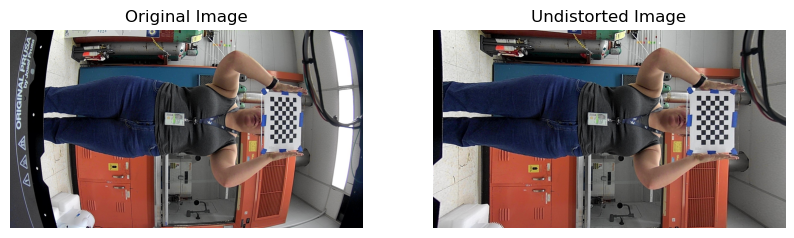

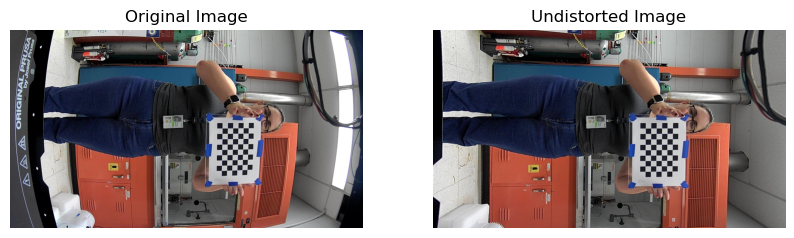

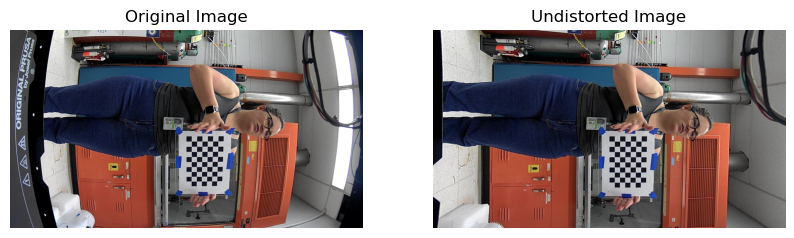

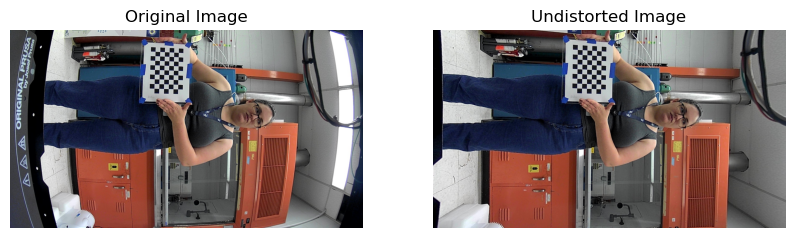

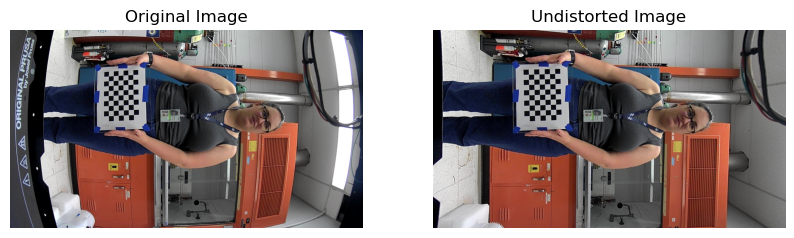

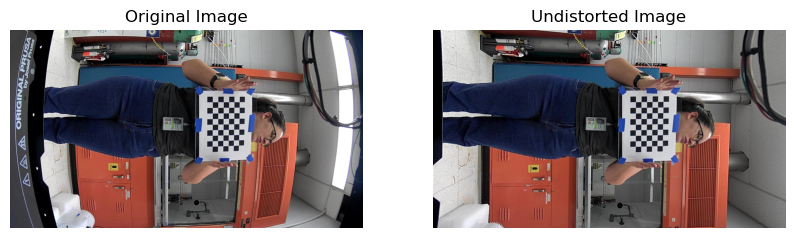

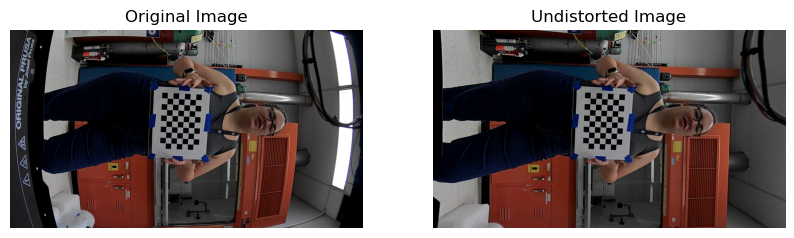

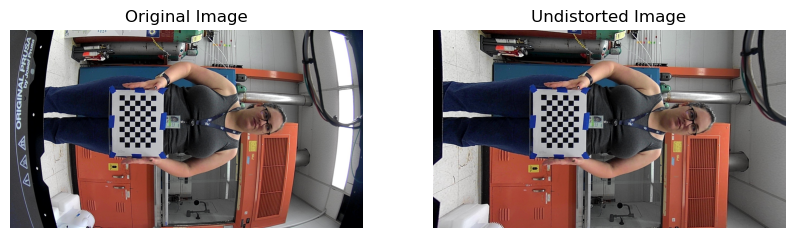

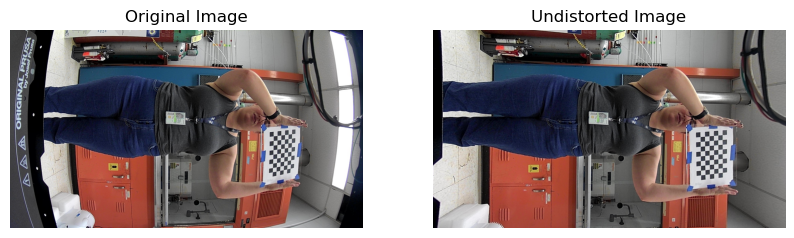

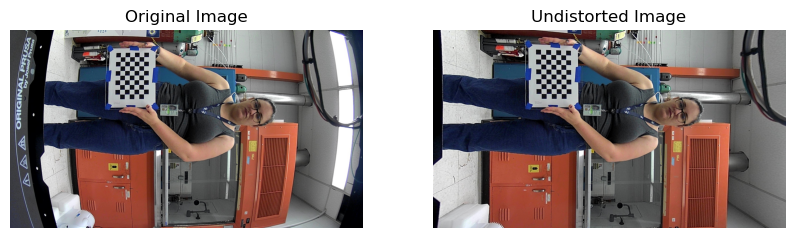

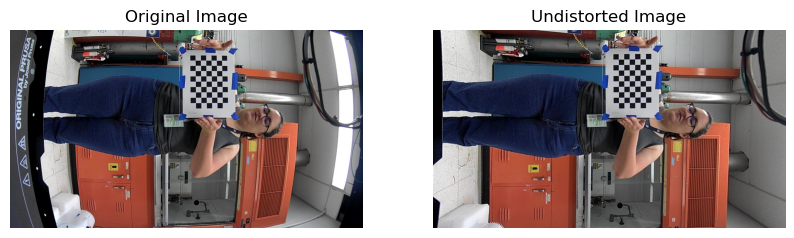

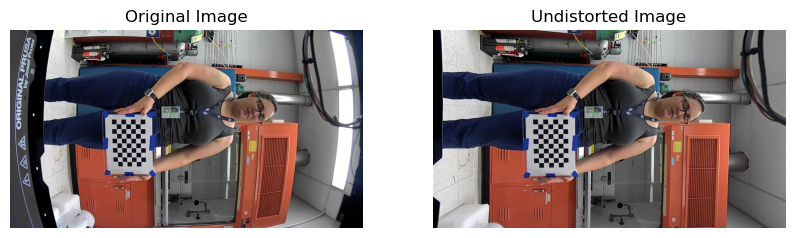

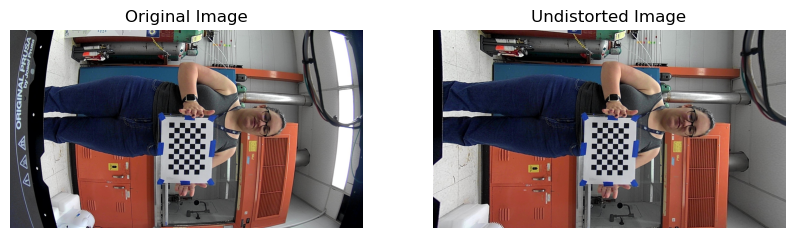

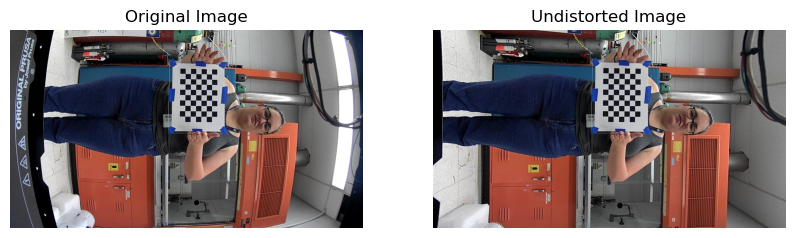

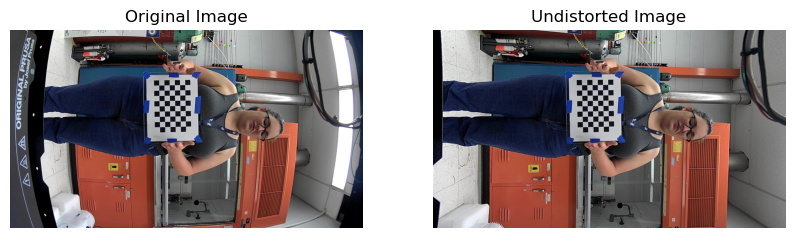

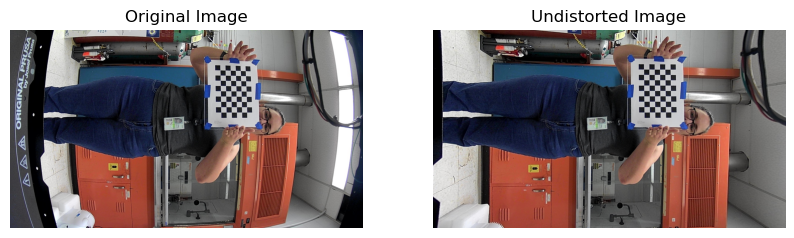

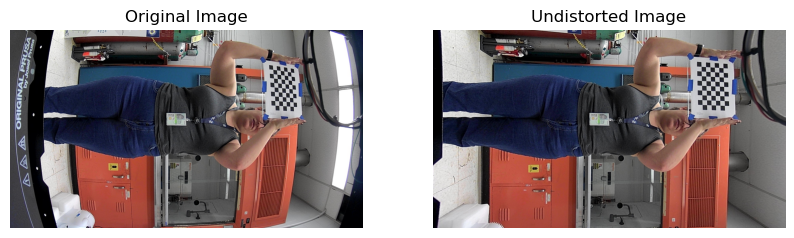

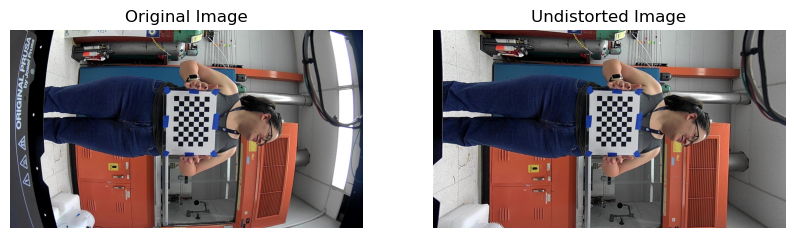

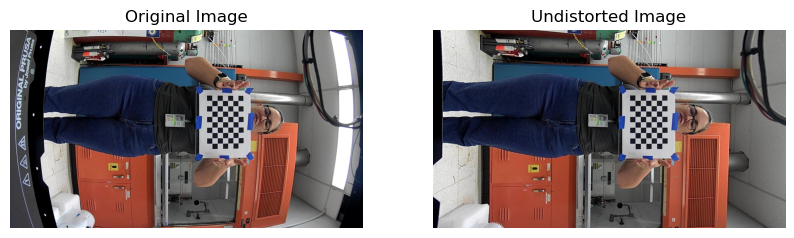

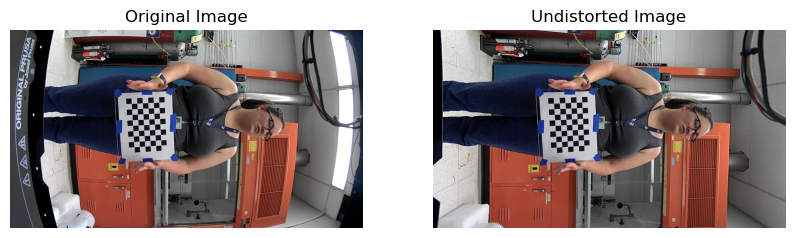

In [4]:
# Plot image and corrected image side by side
for img_file in image_dir.glob('*.jpg'):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    img = cv.imread(str(img_file))

    DIM = img.shape[:2][::-1]

    if cal_type == 'chessboard':
        K = K
        D = D
        map1, map2 = cv.fisheye.initUndistortRectifyMap(K, D, np.eye(3), K, DIM, cv.CV_16SC2)
    elif cal_type == 'circles':
        K = mtx
        D = dist    
        map1, map2 = cv.initUndistortRectifyMap(K, D, np.eye(3), K, DIM, cv.CV_16SC2)

    dst = cv.remap(img, map1, map2, interpolation=cv.INTER_LINEAR,borderMode=cv.BORDER_CONSTANT)

    ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    ax[1].imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))
    ax[1].set_title('Undistorted Image')
    ax[1].axis('off')
    plt.show()
